In [5]:
!pip install matplotlib

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [14]:
image = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

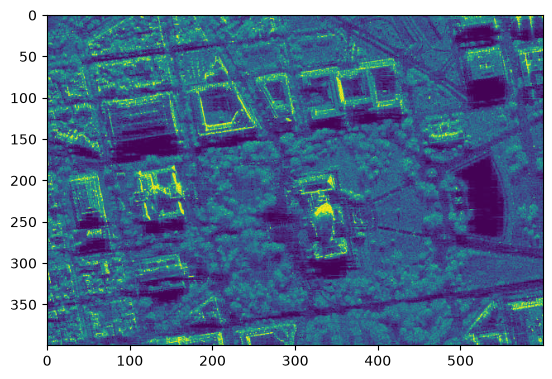

In [15]:
plt.imshow(image)

In [16]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)

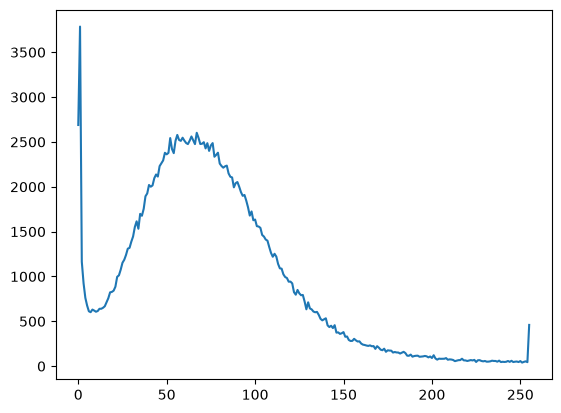

In [17]:
plt.plot(b_hist)

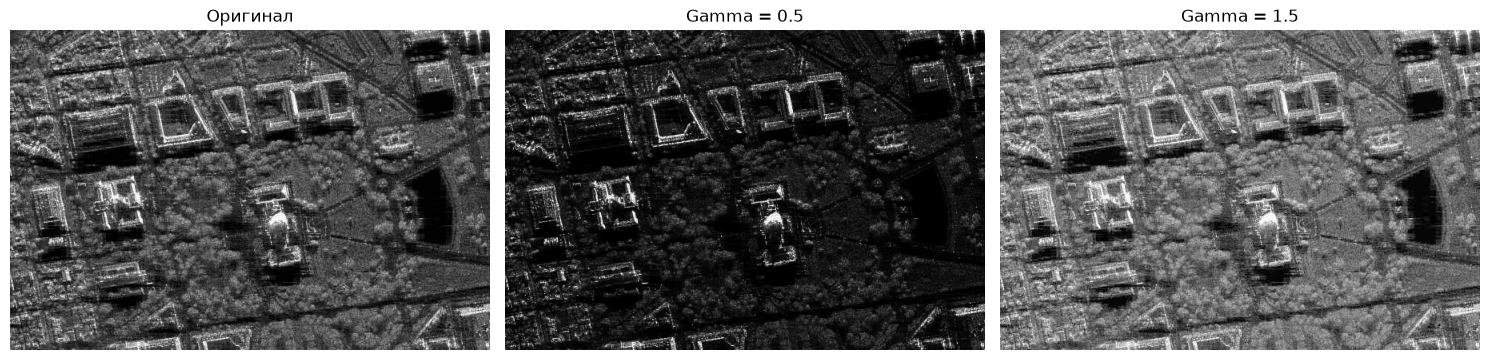

Гамма-коррекция
Оригинал:     mean = 74.94, std = 43.66
Gamma = 0.5:  mean = 29.07, std = 34.80
Gamma = 1.5:  mean = 107.40, std = 44.86


In [18]:
def gamma_correction(img, gamma=1.0):
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(img, table)

# y < 1 — осветление
gamma_light = gamma_correction(image, gamma=0.5)

# y > 1 — затемнение
gamma_dark = gamma_correction(image, gamma=1.5)

# Вывод результата
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(image, cmap='gray'), plt.title('Оригинал'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(gamma_light, cmap='gray'), plt.title('Gamma = 0.5'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(gamma_dark, cmap='gray'), plt.title('Gamma = 1.5'), plt.axis('off')
plt.tight_layout()
plt.show()

print("Гамма-коррекция")
print(f"Оригинал:     mean = {image.mean():.2f}, std = {image.std():.2f}")
print(f"Gamma = 0.5:  mean = {gamma_light.mean():.2f}, std = {gamma_light.std():.2f}")
print(f"Gamma = 1.5:  mean = {gamma_dark.mean():.2f}, std = {gamma_dark.std():.2f}")

In [19]:
mse_light = mean_squared_error(image, gamma_light)
ssim_light, _ = structural_similarity(image, gamma_light, data_range=255, full=True)

mse_dark = mean_squared_error(image, gamma_dark)
ssim_dark, _ = structural_similarity(image, gamma_dark, data_range=255, full=True)

print("Сравнение MSE и SSIM") 
print(f"Gamma = 0.5 -> MSE = {mse_light:.2f}, SSIM = {ssim_light:.4f}")
print(f"Gamma = 1.5 -> MSE = {mse_dark:.2f}, SSIM = {ssim_dark:.4f}")

Сравнение MSE и SSIM
Gamma = 0.5 -> MSE = 2383.76, SSIM = 0.5270
Gamma = 1.5 -> MSE = 1114.45, SSIM = 0.8940


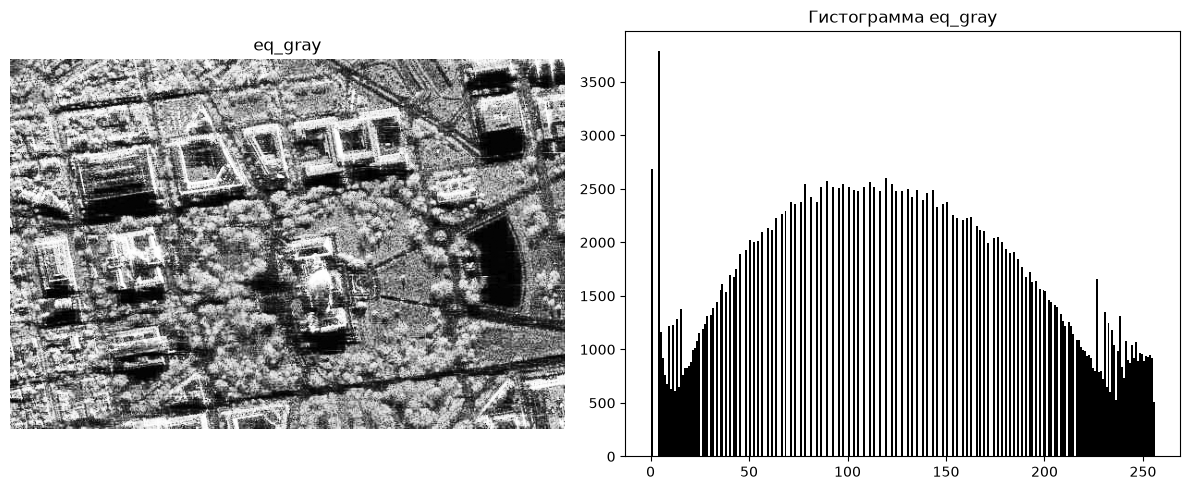

Эквализация гистограммы
До эквализации:  mean = 74.94, std = 43.66
После эквализации: mean = 127.03, std = 74.27


In [20]:
eq_gray = cv2.equalizeHist(image)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1), plt.imshow(eq_gray, cmap='gray'), plt.title('eq_gray'), plt.axis('off')
plt.subplot(1, 2, 2), plt.hist(eq_gray.ravel(), 256, [0, 256], color='black')
plt.title('Гистограмма eq_gray')
plt.tight_layout()
plt.show()

print("Эквализация гистограммы")
print(f"До эквализации:  mean = {image.mean():.2f}, std = {image.std():.2f}")
print(f"После эквализации: mean = {eq_gray.mean():.2f}, std = {eq_gray.std():.2f}")

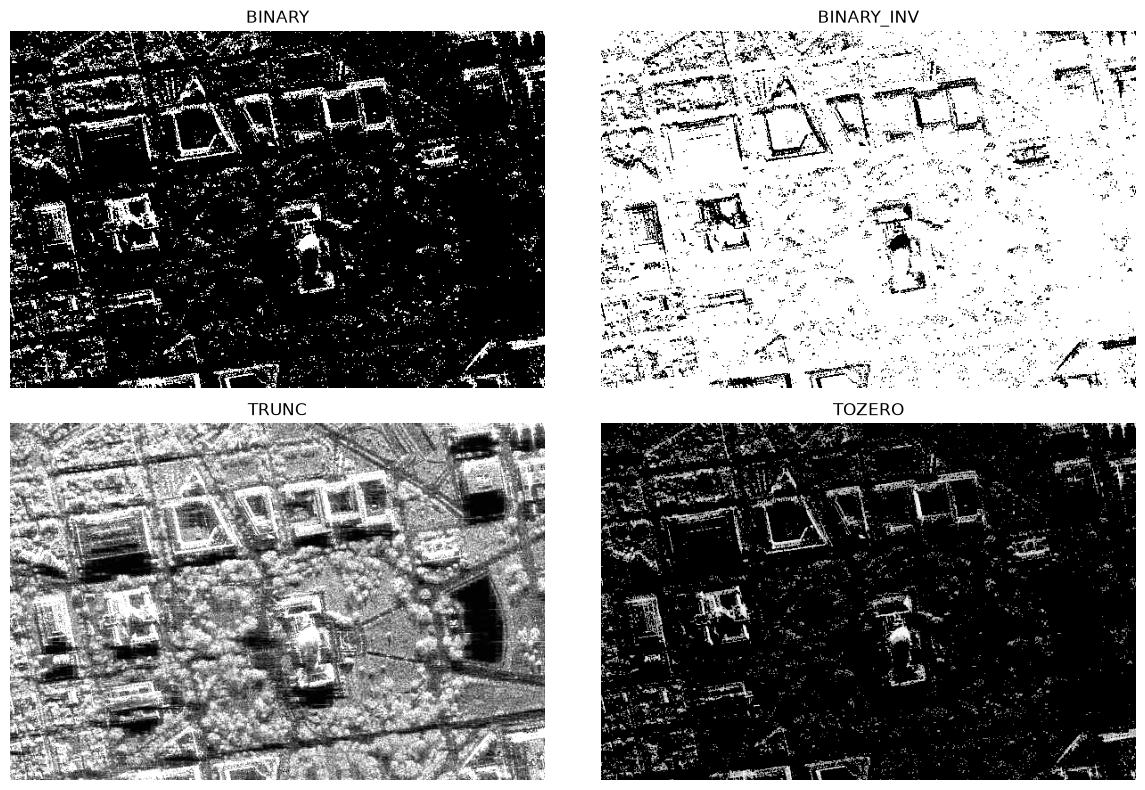

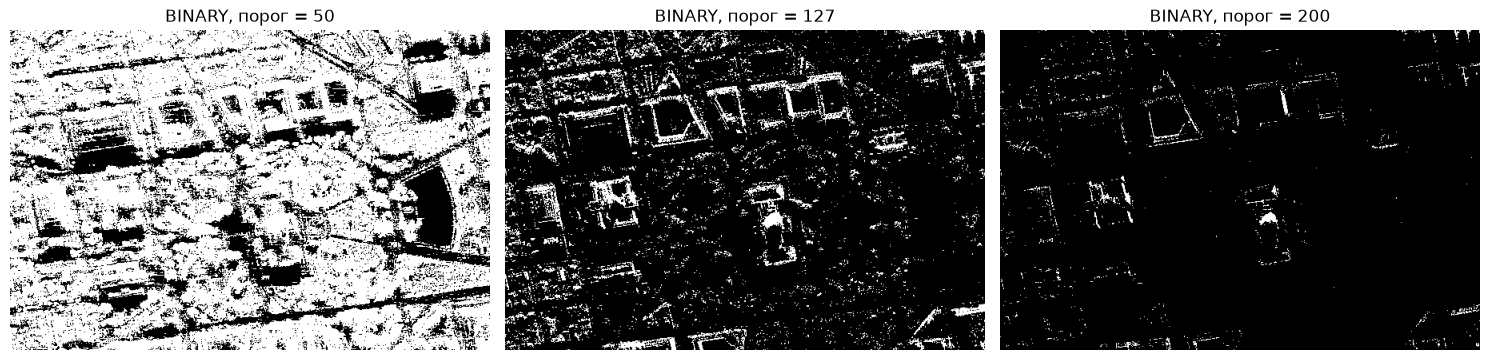

Пороговая фильтрация
BINARY      : белых = 24992, чёрных = 215008
BINARY_INV  : белых = 215008, чёрных = 24992
TRUNC       : белых = 0, чёрных = 2689
TOZERO      : белых = 460, чёрных = 215008


In [22]:
# Разные виды пороговой обработки при одном пороге = 127
ret, th_binary     = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
ret, th_binary_inv = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
ret, th_trunc      = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)
ret, th_tozero     = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)

titles = ['BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO']
imgs   = [th_binary, th_binary_inv, th_trunc, th_tozero]

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(imgs[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

# Разные значения порога для BINARY
plt.figure(figsize=(15, 4))
for i, t in enumerate([50, 127, 200]):
    _, th = cv2.threshold(image, t, 255, cv2.THRESH_BINARY)
    plt.subplot(1, 3, i + 1)
    plt.imshow(th, cmap='gray')
    plt.title(f'BINARY, порог = {t}')
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Пороговая фильтрация")
for name, im in zip(titles, imgs):
    white = int((im == 255).sum())
    black = int((im == 0).sum())
    print(f"{name:12s}: белых = {white}, чёрных = {black}")